In [35]:
import numpy as np
import matplotlib.pyplot as plt

N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.6727, 1.64238, 1.64238]

ratio = (thick.sum() + gaps.sum()) / 40.0
radii = 0.5 * np.array([41.5, 30.0, 20.0, 19.0, 25.0]) * ratio
APERTURE_RADIUS = 0.5 * 3.0 * ratio

LENS = list(zip(
    [0.0, curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [13.0 * ratio, thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [N_AIR, n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [radii[0], radii[1], radii[1], radii[1], radii[1], radii[2], APERTURE_RADIUS, radii[3], radii[4], radii[4], radii[4], radii[4]]
) )
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    return eta * direction + (eta * cos_i - cos_t) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, 1.0])
        if np.dot(direction, normal) > 0.0:
            normal = -normal
        return hit, normal
    radius = abs(curvature)
    center = np.array([0.0, 0.0, z_surface + curvature])
    oc = origin - center
    a = np.dot(direction, direction)
    b = np.dot(oc, direction)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - a * c
    if disc < 0.0:
        return None
    sqrt_disc = np.sqrt(disc)
    t0 = (-b - sqrt_disc) / a
    t1 = (-b + sqrt_disc) / a
    if t0 > t1:
        t0, t1 = t1, t0
    use_first = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = t0 if use_first else t1
    if t <= 0.0:
        return None
    hit = origin + t * direction
    normal = hit - center
    normal /= np.linalg.norm(normal)
    if np.dot(direction, normal) > 0.0:
        normal = -normal
    return hit, normal

def trace_ray(ray_origin, target_point, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return None
    direction /= norm_dir
    path = [origin.copy()] if record_path else None
    z_surface = 0.0
    n_current = N_AIR
    for curvature, thickness, n_next, aperture in LENS:
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return None
        hit, normal = result
        if aperture > 0.0 and hit[0] * hit[0] + hit[1] * hit[1] > aperture * aperture:
            return None
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return None
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        if record_path:
            path.append(origin.copy())
        n_current = n_next
        z_surface += thickness
    return {
        "position": origin,
        "direction": direction,
        "path": np.vstack(path) if record_path else None
    }

def focus_from_two_rays(object_distance_mm, entry_scale=0.8, record_paths=False):
    origin = np.array([0.0, 0.0, -object_distance_mm], dtype=float)
    entry = entry_scale * APERTURE_RADIUS
    aims = (np.array([0.0, 0.0, 0.0]), np.array([entry, 0.0, 0.0]))
    rays = [trace_ray(origin, aim, record_paths) for aim in aims]
    if any(ray is None for ray in rays):
        return None
    p1, d1 = rays[0]["position"], rays[0]["direction"]
    p2, d2 = rays[1]["position"], rays[1]["direction"]
    a = np.dot(d1, d1)
    b = np.dot(d1, d2)
    c = np.dot(d2, d2)
    w0 = p1 - p2
    d = np.dot(d1, w0)
    e = np.dot(d2, w0)
    denom = a * c - b * b
    if abs(denom) < 1e-12:
        return None
    t1 = (b * e - c * d) / denom
    t2 = (a * e - b * d) / denom
    q1 = p1 + t1 * d1
    q2 = p2 + t2 * d2
    focus_point = 0.5 * (q1 + q2)
    result = {
        "point": focus_point,
        "residual_mm": np.linalg.norm(q1 - q2),
    }
    if record_paths:
        result["paths"] = [r["path"] for r in rays]
    return result

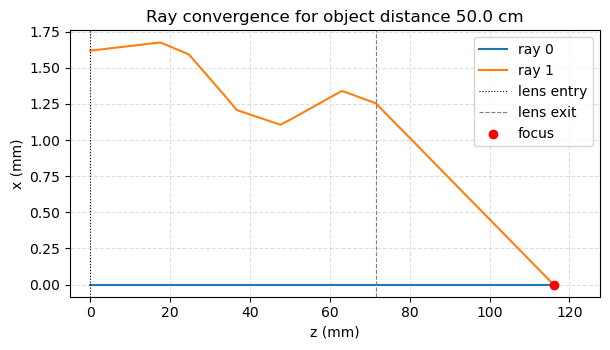

Object distance: 50.000 cm
Distance beyond lens exit: 44.546 mm
Ray intersection residual: 0.000 µm


In [36]:
object_distance_cm = 50.0
focus_info = focus_from_two_rays(object_distance_cm * 10.0, record_paths=True)

if focus_info is None:
    print("Ray tracing failed for the selected object distance.")
else:
    focus = focus_info["point"]
    residual_um = focus_info["residual_mm"] * 1e3

    plt.figure(figsize=(6.2, 3.6))
    for idx, path in enumerate(focus_info.get("paths", [])):
        segment = path[path[:, 2] >= -5.0]
        curve = np.vstack([segment, focus])
        plt.plot(curve[:, 2], curve[:, 0], label=f"ray {idx}")
    plt.axvline(0.0, color="black", linewidth=0.8, linestyle=":", label="lens entry")
    plt.axvline(LENS_LENGTH_MM, color="gray", linewidth=0.8, linestyle="--", label="lens exit")
    plt.scatter([focus[2]], [focus[0]], color="red", zorder=5, label="focus")
    plt.xlabel("z (mm)")
    plt.ylabel("x (mm)")
    plt.title(f"Ray convergence for object distance {object_distance_cm:.1f} cm")
    plt.xlim(-5.0, focus[2] * 1.1)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Object distance: {object_distance_cm:.3f} cm")
    print(f"Distance beyond lens exit: {focus[2] - LENS_LENGTH_MM:.3f} mm")
    print(f"Ray intersection residual: {residual_um:.3f} µm")

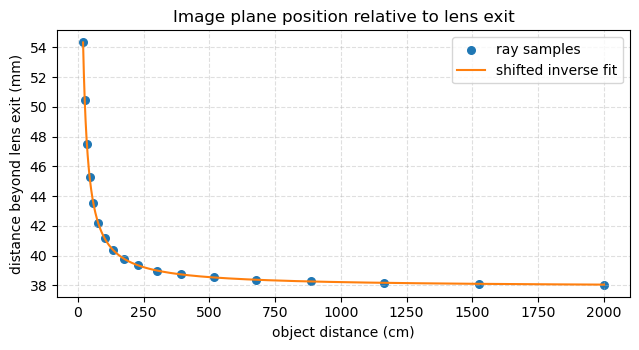

Rational function fit: f(x_cm) = a / (x_cm + b) + c
  a ≈ 335.598 mm·cm
  b ≈ 0.400 cm
  c ≈ 37.887 mm
  MSE ≈ 0.0000 mm^2


In [37]:
from scipy.optimize import curve_fit

object_distances_cm = np.geomspace(20.0, 2000.0, 18)
samples = []
for dist_cm in object_distances_cm:
    focus = focus_from_two_rays(dist_cm * 10.0)
    if focus is None or focus["residual_mm"] > 1e-3:
        continue
    samples.append((dist_cm, focus["point"][2] - LENS_LENGTH_MM))

if not samples:
    print("No focus samples collected.")
else:
    obj_cm, offset_mm = np.array(samples).T
    order = np.argsort(obj_cm)
    obj_cm = obj_cm[order]
    offset_mm = offset_mm[order]

    def rational_function_mm(x_cm, a, b, c):
        return a / (x_cm + b) + c

    popt, _ = curve_fit(rational_function_mm, obj_cm, offset_mm, p0=(5000.0, 0.0, 40.0), maxfev=20000)
    obj_fit = np.geomspace(obj_cm.min(), obj_cm.max(), 200)
    offset_fit = rational_function_mm(obj_fit, *popt)

    plt.figure(figsize=(6.5, 3.6))
    plt.scatter(obj_cm, offset_mm, s=30, label="ray samples")
    plt.plot(obj_fit, offset_fit, color="tab:orange", label="shifted inverse fit")
    plt.xlabel("object distance (cm)")
    plt.ylabel("distance beyond lens exit (mm)")
    plt.title("Image plane position relative to lens exit")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    mse = float(np.mean((rational_function_mm(obj_cm, *popt) - offset_mm) ** 2))
    a_fit, b_fit, c_fit = popt
    print("Rational function fit: f(x_cm) = a / (x_cm + b) + c")
    print(f"  a ≈ {a_fit:.3f} mm·cm")
    print(f"  b ≈ {b_fit:.3f} cm")
    print(f"  c ≈ {c_fit:.3f} mm")
    print(f"  MSE ≈ {mse:.4f} mm^2")